# 11b — Final Presentation Visuals 

## Objective

This notebook generates **presentation-ready visuals** for the final 5-minute Boom Challenge video.

The visual style is aligned with the PowerPoint deck:

- dark navy title color;
- green / teal gradient palette;
- highlighted final model `hybrid_w_0.65`;
- clean labels and direct value annotations;
- explicit note that scoring charts are **validation proxies**, not official leaderboard scores.

Generated figures are saved to:

```text
outputs/figures/final_presentation/
```


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FINAL_FIGURES_DIR = FIGURES_DIR / "final_presentation"

for p in [OUTPUTS_DIR, SUBMISSIONS_DIR, REPORTS_DIR, FIGURES_DIR, FINAL_FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Reports:", REPORTS_DIR)
print("Final figures:", FINAL_FIGURES_DIR)


Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Reports: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports
Final figures: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/final_presentation


## 1. Visual theme

The color palette is designed to match the final PowerPoint style:

- **navy** for titles and text;
- **green highlight** for the final retained model;
- **teal gradient** for alternative strategies;
- **light grid** for readability.


In [2]:
NAVY = "#0F2442"
TEAL_DARK = "#2F8F83"
TEAL = "#36A08C"
GREEN = "#41B86A"
GREEN_LIGHT = "#7EDB9B"
MINT = "#DFF4E8"
GRAY = "#6C7580"
LIGHT_GRID = "#D8E3EA"
ORANGE = "#E76F51"

FINAL_STRATEGY = "hybrid_w_0.65"

OFFICIAL_TARGET_WEIGHTS = {
    "P80": 0.30,
    "R95": 0.20,
    "fines_frac": 0.15,
    "oversize_frac": 0.15,
    "R50_fines": 0.10,
    "R50_oversize": 0.10,
}

target_cols = ["P80", "fines_frac", "oversize_frac", "R95", "R50_fines", "R50_oversize"]
distance_cols = ["R95", "R50_fines", "R50_oversize"]
fraction_cols = ["fines_frac", "oversize_frac"]


def blend(color1, color2, t):
    c1 = np.array(to_rgb(color1))
    c2 = np.array(to_rgb(color2))
    return tuple(c1 * (1 - t) + c2 * t)


def gradient_colors(n, start=TEAL_DARK, end=GREEN_LIGHT):
    if n <= 1:
        return [end]
    return [blend(start, end, i / (n - 1)) for i in range(n)]


def clean_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#B8C4CC")
    ax.spines["bottom"].set_color("#B8C4CC")
    ax.grid(axis=grid_axis, color=LIGHT_GRID, linestyle="-", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#1E2933")


def save_fig(fig, filename):
    path = FINAL_FIGURES_DIR / filename
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    print("Saved:", path)
    return path


plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlecolor": NAVY,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "DejaVu Sans",
})


## 2. Official target weights visual



> P80 and R95 together represent 50% of the forward prediction score.


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/final_presentation/01_official_target_weights_gradient.png


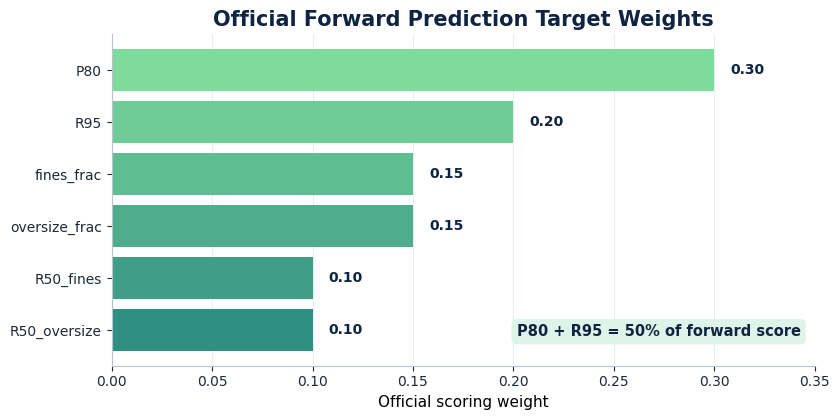

In [3]:
weights_df = (
    pd.DataFrame([
        {"target": t, "weight": w, "metric": "sMAPE" if t in fraction_cols else "MAE"}
        for t, w in OFFICIAL_TARGET_WEIGHTS.items()
    ])
    .sort_values("weight", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8.5, 4.3))
colors = gradient_colors(len(weights_df), start=TEAL_DARK, end=GREEN_LIGHT)

bars = ax.barh(weights_df["target"], weights_df["weight"], color=colors, edgecolor="none")

for bar, value in zip(bars, weights_df["weight"]):
    ax.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=NAVY,
    )

ax.set_title("Official Forward Prediction Target Weights")
ax.set_xlabel("Official scoring weight")
ax.set_xlim(0, 0.35)
clean_axes(ax)

ax.text(
    0.98, 0.08,
    "P80 + R95 = 50% of forward score",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.5,
    color=NAVY,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor=MINT, edgecolor="none"),
)

plt.tight_layout()
save_fig(fig, "01_official_target_weights_gradient.png")
plt.show()


## 3. Load LOGO reports and compute scoring proxies

Expected files:

```text
reports/16_logo_metrics_by_strategy_target.csv
data/raw/forward_prediction/train_labels.csv
```

The **relative LOGO proxy score** is:

```text
relative_error = MAE / mean(|target|)
proxy_score = 100 / (1 + weighted_relative_error)
```

This is a validation proxy, not an official leaderboard score.


In [4]:
logo_metrics_path = REPORTS_DIR / "16_logo_metrics_by_strategy_target.csv"
labels_path = PROJECT_ROOT / "data" / "raw" / "forward_prediction" / "train_labels.csv"

if not logo_metrics_path.exists():
    raise FileNotFoundError(f"Missing {logo_metrics_path}. Run the LOGO notebook first.")

logo_metrics = pd.read_csv(logo_metrics_path)

if labels_path.exists():
    y_train = pd.read_csv(labels_path)[target_cols]
    target_means = y_train.abs().mean().to_dict()
else:
    y_train = None
    target_means = {}
    print("Warning: train_labels.csv not found. The notebook will fallback to normalized_MAE where possible.")

display(logo_metrics.head())


,MAE,RMSE,R2,Median_AE,P90_AE,P95_AE,Bias,normalized_MAE,strategy,target
0,7.841240,10.349198,0.975220,6.103239,17.106831,21.382564,0.437683,0.119249,base,P80
1,0.006575,0.014336,0.956317,0.000689,0.020490,0.031476,0.000040,0.095837,base,fines_frac
2,0.027178,0.036240,0.989979,0.020729,0.058331,0.074488,0.001192,0.075058,base,oversize_frac
3,167.620273,216.090554,0.179108,125.978141,328.157450,457.328480,-21.256844,0.702683,base,R95
4,224.926193,261.725704,-0.124096,168.475984,425.978269,508.029820,-23.938028,0.911006,base,R50_fines


In [5]:
proxy_rows = []

for strategy, group in logo_metrics.groupby("strategy"):
    row = {"strategy": strategy}
    weighted_relative_error = 0.0
    weighted_raw_error = 0.0

    for target, weight in OFFICIAL_TARGET_WEIGHTS.items():
        target_row = group[group["target"] == target]
        if target_row.empty:
            row[f"{target}_relative_error"] = np.nan
            row[f"{target}_weighted_relative"] = np.nan
            continue

        mae_value = float(target_row["MAE"].iloc[0])
        raw_error = mae_value

        if target in target_means:
            relative_error = mae_value / (target_means[target] + 1e-9)
        elif "normalized_MAE" in target_row.columns:
            relative_error = float(target_row["normalized_MAE"].iloc[0])
        else:
            relative_error = mae_value

        row[f"{target}_raw_error"] = raw_error
        row[f"{target}_relative_error"] = relative_error
        row[f"{target}_weighted_raw"] = weight * raw_error
        row[f"{target}_weighted_relative"] = weight * relative_error

        weighted_raw_error += weight * raw_error
        weighted_relative_error += weight * relative_error

    row["weighted_raw_error"] = weighted_raw_error
    row["raw_proxy_score"] = 100 / (1 + weighted_raw_error)
    row["weighted_relative_error"] = weighted_relative_error
    row["relative_proxy_score"] = 100 / (1 + weighted_relative_error)

    proxy_rows.append(row)

score_proxy_df = (
    pd.DataFrame(proxy_rows)
    .sort_values("relative_proxy_score", ascending=False)
    .reset_index(drop=True)
)

display(score_proxy_df[["strategy", "weighted_relative_error", "relative_proxy_score", "weighted_raw_error", "raw_proxy_score"]])

score_proxy_df.to_csv(REPORTS_DIR / "11b_gradient_relative_logo_proxy_scores.csv", index=False)


,strategy,weighted_relative_error,relative_proxy_score,weighted_raw_error,raw_proxy_score
0,hybrid_w_0.65,0.162344,86.033073,29.695693,3.257786
1,physics_residual,0.185972,84.319058,35.722271,2.723143
2,alpha25,0.278148,78.238177,57.438058,1.711214
3,base,0.319081,75.810383,67.239189,1.465434


## 4. Main final result visual — Relative LOGO proxy score




> This is not the leaderboard score. It is a validation proxy aligned with the official scoring weights.


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/final_presentation/02_relative_logo_proxy_score_gradient.png


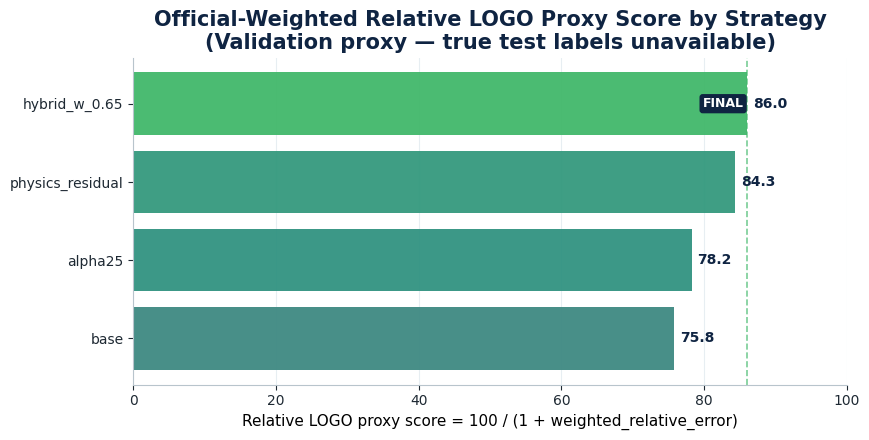

In [6]:
plot_df = score_proxy_df.sort_values("relative_proxy_score", ascending=True).reset_index(drop=True)

colors = []
for strategy in plot_df["strategy"]:
    if strategy == FINAL_STRATEGY:
        colors.append(GREEN)
    elif strategy == "physics_residual":
        colors.append(blend(TEAL_DARK, GREEN, 0.25))
    elif strategy == "alpha25":
        colors.append(blend(TEAL_DARK, GREEN, 0.10))
    else:
        colors.append(blend(TEAL_DARK, GRAY, 0.25))

fig, ax = plt.subplots(figsize=(8.8, 4.5))
bars = ax.barh(plot_df["strategy"], plot_df["relative_proxy_score"], color=colors, edgecolor="none", alpha=0.95)

for bar, value, strategy in zip(bars, plot_df["relative_proxy_score"], plot_df["strategy"]):
    ax.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=10,
        color=NAVY,
        fontweight="bold",
    )
    if strategy == FINAL_STRATEGY:
        ax.axvline(value, color=GREEN, linestyle="--", linewidth=1.2, alpha=0.7)
        ax.text(
            value - 0.5,
            bar.get_y() + bar.get_height() / 2,
            "FINAL",
            va="center",
            ha="right",
            fontsize=9,
            color="white",
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", facecolor=NAVY, edgecolor="none"),
        )

ax.set_title("Official-Weighted Relative LOGO Proxy Score by Strategy\n(Validation proxy — true test labels unavailable)")
ax.set_xlabel("Relative LOGO proxy score = 100 / (1 + weighted_relative_error)")
ax.set_xlim(0, max(100, plot_df["relative_proxy_score"].max() + 8))
clean_axes(ax)

plt.tight_layout()
save_fig(fig, "02_relative_logo_proxy_score_gradient.png")
plt.show()


## 5. Weighted relative contribution by target



> Even after weighting and normalization, the distance targets — especially R95 — remain the main source of validation error. This explains why the hybrid model focuses on distance robustness.


In [7]:
selected = score_proxy_df[score_proxy_df["strategy"] == FINAL_STRATEGY]
if selected.empty:
    selected = score_proxy_df.iloc[[0]]
    selected_strategy = selected.iloc[0]["strategy"]
    print("Final strategy not found. Using:", selected_strategy)
else:
    selected_strategy = FINAL_STRATEGY

selected_row = selected.iloc[0]

contrib_rows = []
for target, weight in OFFICIAL_TARGET_WEIGHTS.items():
    contrib_rows.append({
        "target": target,
        "weight": weight,
        "relative_error": selected_row[f"{target}_relative_error"],
        "weighted_relative_contribution": selected_row[f"{target}_weighted_relative"],
    })

contrib_df = (
    pd.DataFrame(contrib_rows)
    .sort_values("weighted_relative_contribution", ascending=True)
    .reset_index(drop=True)
)

display(contrib_df)
contrib_df.to_csv(REPORTS_DIR / "11b_gradient_weighted_relative_contribution_final.csv", index=False)


,target,weight,relative_error,weighted_relative_contribution
0,oversize_frac,0.15,0.052902,0.007935
1,P80,0.30,0.045617,0.013685
2,fines_frac,0.15,0.149887,0.022483
3,R50_fines,0.10,0.275852,0.027585
4,R50_oversize,0.10,0.330257,0.033026
5,R95,0.20,0.288147,0.057629


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/final_presentation/03_weighted_relative_contribution_gradient.png


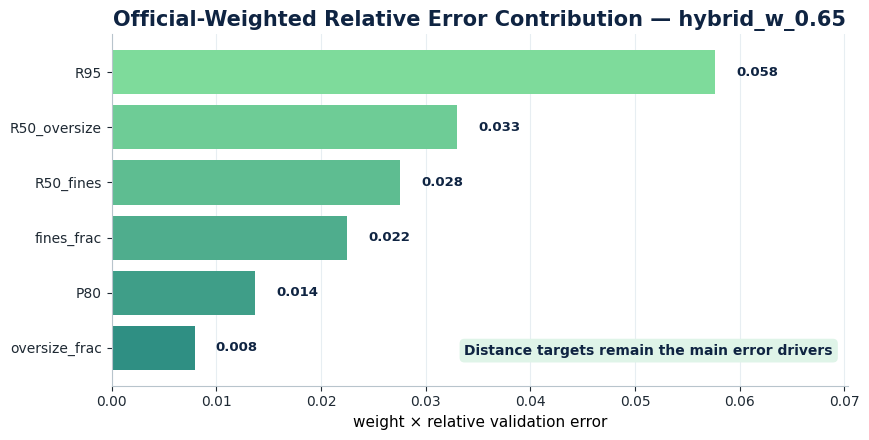

In [8]:
fig, ax = plt.subplots(figsize=(8.8, 4.5))
colors = gradient_colors(len(contrib_df), start=TEAL_DARK, end=GREEN_LIGHT)

bars = ax.barh(
    contrib_df["target"],
    contrib_df["weighted_relative_contribution"],
    color=colors,
    edgecolor="none"
)

for bar, value in zip(bars, contrib_df["weighted_relative_contribution"]):
    ax.text(
        value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        ha="left",
        fontsize=9.5,
        color=NAVY,
        fontweight="bold",
    )

ax.set_title(f"Official-Weighted Relative Error Contribution — {selected_strategy}")
ax.set_xlabel("weight × relative validation error")
ax.set_xlim(0, contrib_df["weighted_relative_contribution"].max() * 1.22)
clean_axes(ax)

ax.text(
    0.98, 0.08,
    "Distance targets remain the main error drivers",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color=NAVY,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.35", facecolor=MINT, edgecolor="none"),
)

plt.tight_layout()
save_fig(fig, "03_weighted_relative_contribution_gradient.png")
plt.show()


## 6. LOGO MAE summary for distance targets

This chart explains why the hybrid model exists.

Recommended message:

> The hybrid model is not used everywhere. It is used where the problem is hardest: distance targets under unseen gravity.


In [9]:
distance_metrics = logo_metrics[logo_metrics["target"].isin(distance_cols)].copy()

preferred_order = [FINAL_STRATEGY, "physics_residual", "alpha25", "base"]
available_order = [s for s in preferred_order if s in distance_metrics["strategy"].unique()]
if not available_order:
    available_order = distance_metrics["strategy"].unique().tolist()

summary_distance = (
    distance_metrics[distance_metrics["strategy"].isin(available_order)]
    .pivot_table(index="target", columns="strategy", values="MAE", aggfunc="mean")
    .reindex(distance_cols)
)

display(summary_distance)


strategy,alpha25,base,hybrid_w_0.65,physics_residual
target,,,,
R95,143.084808,167.620273,72.97614,82.287352
R50_fines,188.334070,224.926193,85.75814,121.285667
R50_oversize,76.302547,88.650806,41.67216,47.787989


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/final_presentation/04_logo_distance_mae_summary_gradient.png


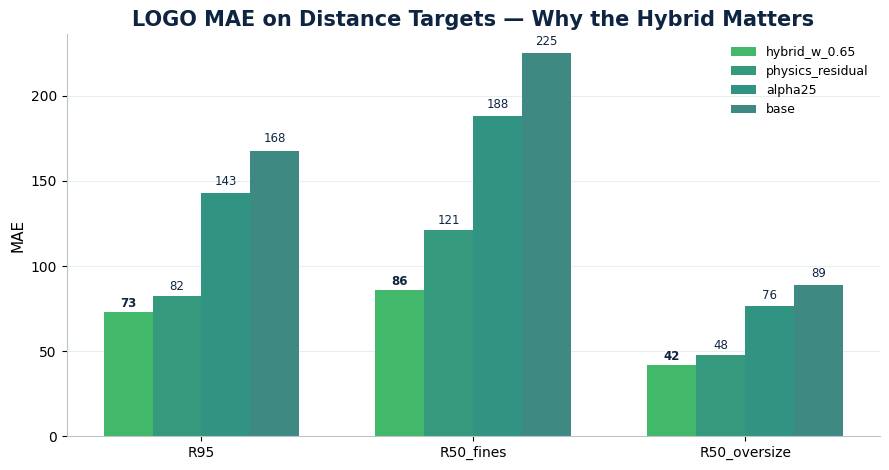

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.8))

x = np.arange(len(distance_cols))
width = 0.18
strategies = [s for s in available_order if s in summary_distance.columns]

strategy_colors = {
    FINAL_STRATEGY: GREEN,
    "physics_residual": blend(TEAL_DARK, GREEN, 0.25),
    "alpha25": blend(TEAL_DARK, GREEN, 0.10),
    "base": blend(TEAL_DARK, GRAY, 0.25),
}

for i, strategy in enumerate(strategies):
    offset = (i - (len(strategies) - 1) / 2) * width
    values = summary_distance[strategy].values
    bars = ax.bar(
        x + offset,
        values,
        width=width,
        label=strategy,
        color=strategy_colors.get(strategy, gradient_colors(len(strategies))[i]),
        edgecolor="none",
    )
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + max(values) * 0.015,
            f"{value:.0f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color=NAVY,
            fontweight="bold" if strategy == FINAL_STRATEGY else "normal",
        )

ax.set_title("LOGO MAE on Distance Targets — Why the Hybrid Matters")
ax.set_ylabel("MAE")
ax.set_xticks(x)
ax.set_xticklabels(distance_cols)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", color=LIGHT_GRID, linestyle="-", linewidth=0.8, alpha=0.6)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#B8C4CC")
ax.spines["bottom"].set_color("#B8C4CC")

plt.tight_layout()
save_fig(fig, "04_logo_distance_mae_summary_gradient.png")
plt.show()


## 7. Optional: LOGO R95 by held-out gravity

This optional chart uses:

```text
reports/13_meta_blend_gravity_breakdown.csv
```


Saved: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/figures/final_presentation/05_logo_r95_by_heldout_gravity_gradient.png


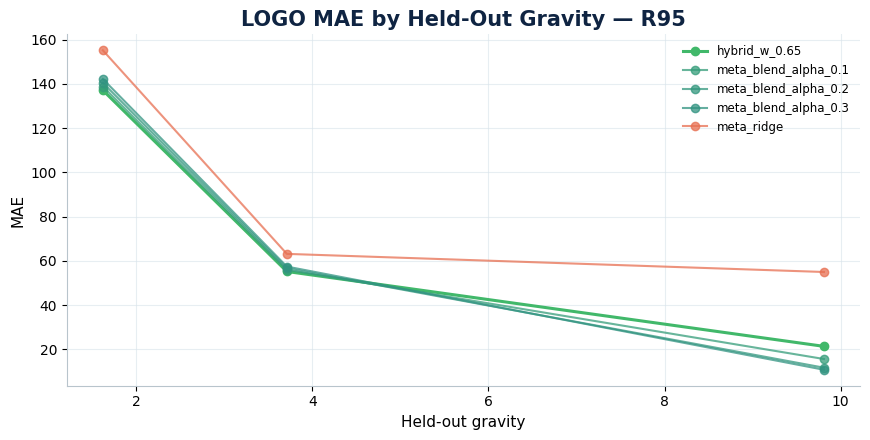

In [11]:
gravity_breakdown_path = REPORTS_DIR / "13_meta_blend_gravity_breakdown.csv"

if gravity_breakdown_path.exists():
    gravity_df = pd.read_csv(gravity_breakdown_path)
    target = "R95"
    temp = gravity_df[
        (gravity_df["target"] == target)
        & (gravity_df["strategy"].isin(["hybrid_w_0.65", "meta_ridge", "meta_blend_alpha_0.1", "meta_blend_alpha_0.2", "meta_blend_alpha_0.3"]))
    ].copy()

    fig, ax = plt.subplots(figsize=(8.8, 4.5))

    strategy_order = ["hybrid_w_0.65", "meta_blend_alpha_0.1", "meta_blend_alpha_0.2", "meta_blend_alpha_0.3", "meta_ridge"]
    strategy_colors = {
        "hybrid_w_0.65": GREEN,
        "meta_blend_alpha_0.1": blend(TEAL_DARK, GREEN, 0.35),
        "meta_blend_alpha_0.2": blend(TEAL_DARK, GREEN, 0.20),
        "meta_blend_alpha_0.3": blend(TEAL_DARK, GREEN, 0.10),
        "meta_ridge": ORANGE,
    }

    for strategy in strategy_order:
        if strategy not in temp["strategy"].unique():
            continue
        t = temp[temp["strategy"] == strategy].sort_values("heldout_gravity")
        ax.plot(
            t["heldout_gravity"],
            t["MAE"],
            marker="o",
            linewidth=2.2 if strategy == FINAL_STRATEGY else 1.5,
            label=strategy,
            color=strategy_colors.get(strategy, TEAL),
            alpha=1 if strategy == FINAL_STRATEGY else 0.75,
        )

    ax.set_title("LOGO MAE by Held-Out Gravity — R95")
    ax.set_xlabel("Held-out gravity")
    ax.set_ylabel("MAE")
    ax.legend(frameon=False, fontsize=8.5)
    ax.grid(axis="both", color=LIGHT_GRID, linestyle="-", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#B8C4CC")
    ax.spines["bottom"].set_color("#B8C4CC")

    plt.tight_layout()
    save_fig(fig, "05_logo_r95_by_heldout_gravity_gradient.png")
    plt.show()
else:
    print("Optional file not found:", gravity_breakdown_path)
